# 1 TLS Non-Markovian Gaussian Fock-Pulse Example

This example injects a Gaussian single-photon Fock pulse into the delayed waveguide.
To avoid changing the project simulation core, the notebook carries its own small evolution helper for correlated input-pulse bins.

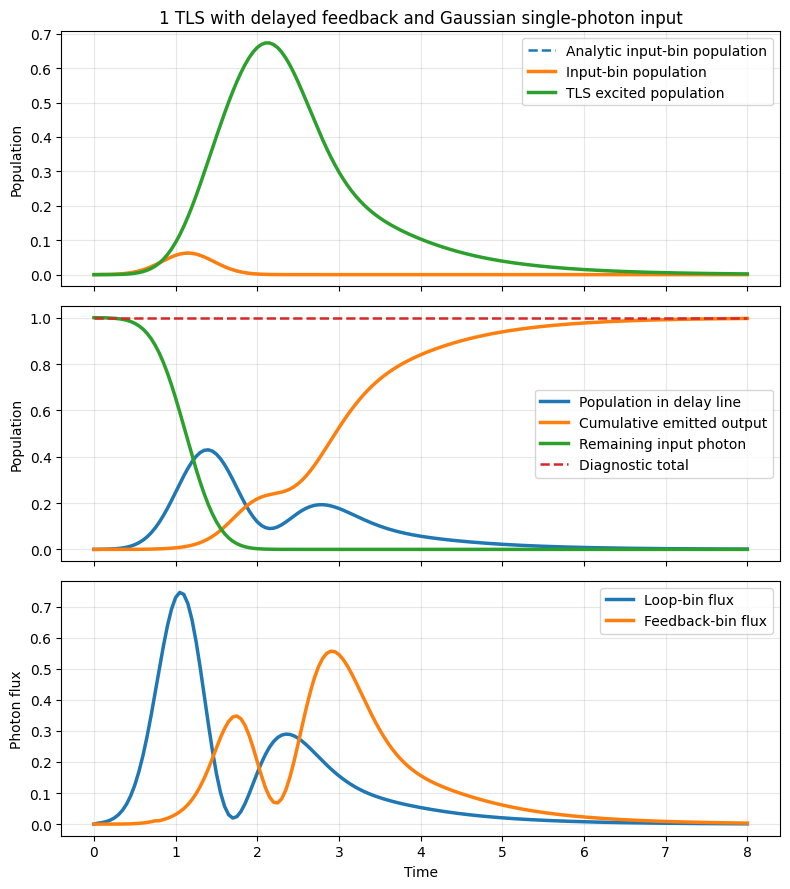

In [ ]:
from __future__ import annotations

import time as t

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la
import wqedmps as qmps
from wqedmps.mps_tools import contract_cached, pair_tensor, swap_pair_tensor
from wqedmps.operators import u_evol


def _delay_window_total(per_bin: np.ndarray, delay_steps: int) -> np.ndarray:
    """Accumulate the population currently stored over one delay window."""
    values = np.asarray(per_bin, dtype=float)
    if delay_steps <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    total = csum.copy()
    if len(values) > delay_steps:
        total[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    return total


def _split_pair(
    theta: np.ndarray, params: qmps.InputParams, keep: str
) -> tuple[np.ndarray, np.ndarray]:
    """Example-local two-site split used for correlated Fock-pulse input bins."""
    left_bond, phys_left, phys_right, right_bond = theta.shape
    matrix = theta.reshape(left_bond * phys_left, phys_right * right_bond)
    u, s, vh = la.svd(matrix, full_matrices=False, lapack_driver=params.svd_driver)

    chi = min(len(s), params.bond_max)
    if params.atol > 0:
        chi = min(chi, max(1, int(np.count_nonzero(s > params.atol))))

    u = u[:, :chi]
    s = s[:chi]
    vh = vh[:chi, :]

    norm = np.linalg.norm(s)
    if norm > 0:
        s = s / norm

    if keep == "left":
        left = (u * s[None, :]).reshape(left_bond, phys_left, chi)
        right = vh.reshape(chi, phys_right, right_bond)
        return left, right

    if keep == "right":
        left = u.reshape(left_bond, phys_left, chi)
        right = (s[:, None] * vh).reshape(chi, phys_right, right_bond)
        return left, right

    raise ValueError("keep must be 'left' or 'right'")


def _evolve_feedback_with_input_mps(
    ham,
    initial_system: np.ndarray,
    input_bins: list[np.ndarray],
    params: qmps.InputParams,
) -> qmps.Bins:
    """Notebook-local non-Markovian evolution for correlated input-pulse bins."""
    d_sys = params.d_sys
    d_bin = params.d_t
    n_steps = params.steps
    delay_steps = params.delay_steps
    if delay_steps < 1:
        raise ValueError("tau must satisfy tau >= delta_t")

    times = np.arange(n_steps + 1) * params.delta_t
    vacuum = qmps.wg_ground(d_bin)
    input_field = qmps.input_state_generator(params.d_t_total, input_bins=input_bins)

    system_tensor = np.asarray(initial_system, dtype=complex)
    delay_line = [vacuum.copy() for _ in range(delay_steps)]

    system_states = [system_tensor.copy()]
    loop_field_states = [vacuum.copy()]
    output_field_states = [vacuum.copy()]
    input_field_states = [vacuum.copy()]
    correlation_bins = [vacuum.copy()]
    last_feedback_center = None

    for step in range(n_steps):
        H = ham(step) if callable(ham) else ham
        U_int = u_evol(H, d_sys, d_bin, 2)

        feedback_bin = delay_line[step]
        for j in range(step, step + delay_steps - 1):
            theta = swap_pair_tensor(feedback_bin, delay_line[j + 1])
            delay_line[j], feedback_bin = _split_pair(theta, params, keep="right")

        theta = pair_tensor(feedback_bin, system_tensor)
        feedback_left, system_tensor = _split_pair(theta, params, keep="right")

        input_bin = np.asarray(next(input_field), dtype=complex)
        theta_in = pair_tensor(system_tensor, input_bin)
        system_left, input_bin_oc = _split_pair(theta_in, params, keep="right")
        input_field_states.append(input_bin_oc.copy())

        theta = contract_cached(
            "aic,cjd,dkb,pqrijk->apqrb",
            feedback_left,
            system_left,
            input_bin_oc,
            U_int,
        )

        theta = theta.reshape(theta.shape[0], d_bin, d_sys * d_bin, theta.shape[-1])
        feedback_left_new, rest_oc = _split_pair(theta, params, keep="right")

        theta = rest_oc.reshape(rest_oc.shape[0], d_sys, d_bin, rest_oc.shape[-1])
        system_centered, loop_bin = _split_pair(theta, params, keep="left")
        system_states.append(system_centered.copy())

        theta = swap_pair_tensor(system_centered, loop_bin)
        loop_bin_centered, system_tensor = _split_pair(theta, params, keep="left")

        theta = pair_tensor(feedback_left_new, loop_bin_centered)
        feedback_bin_centered, loop_bin_internal = _split_pair(
            theta, params, keep="left"
        )
        feedback_view, loop_bin_oc = _split_pair(theta, params, keep="right")

        output_field_states.append(feedback_bin_centered.copy())
        loop_field_states.append(loop_bin_oc.copy())

        delay_line[step + delay_steps - 1] = feedback_bin_centered
        delay_line.append(loop_bin_internal)

        if delay_steps == 1:
            correlation_bins.append(feedback_bin_centered.copy())
            last_feedback_center = feedback_bin_centered.copy()
        else:
            current_feedback = feedback_bin_centered
            theta_for_correlation = None

            for j in range(step + delay_steps - 1, step, -1):
                theta = swap_pair_tensor(delay_line[j - 1], current_feedback)
                theta_for_correlation = theta.copy()
                current_feedback, delay_line[j] = _split_pair(
                    theta, params, keep="left"
                )

            correlation_tensor, delayed_bin = _split_pair(
                theta_for_correlation, params, keep="right"
            )
            delay_line[step + 1] = delayed_bin
            correlation_bins.append(correlation_tensor.copy())
            last_feedback_center = current_feedback.copy()

    if n_steps > 0 and last_feedback_center is not None:
        correlation_bins[-1] = last_feedback_center

    filler = [np.array([1.0], dtype=float) for _ in range(len(system_states))]
    return qmps.Bins(
        system_states=system_states,
        loop_field_states=loop_field_states,
        output_field_states=output_field_states,
        input_field_states=input_field_states,
        correlation_bins=correlation_bins,
        schmidt=filler,
        schmidt_tau=filler,
        bond_dims=[1] * len(system_states),
        bond_dims_tau=[1] * len(system_states),
        times=times,
    )


def run_feedback_tls_gaussian_fock_pulse_example(
    show: bool = True,
) -> tuple[qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]]:
    """Run a 1-TLS delayed-feedback example with a Gaussian single-photon pulse."""
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=8.0,
        tau=0.75,
        d_sys_total=np.array([2]),
        d_t_total=np.array([2]),
        gamma_l=0.5,
        gamma_r=0.5,
        phase=np.pi / 3.0,
        bond_max=18,
        atol=1e-12,
    )

    pulse_time = 3.0
    raw_envelope = qmps.gaussian_envelope(
        pulse_time=pulse_time,
        params=params,
        gaussian_width=0.45,
        gaussian_center=1.1,
    )
    normalized_envelope = qmps.normalize_pulse_envelope(params.delta_t, raw_envelope)
    input_pulse = qmps.fock_pulse(
        normalized_envelope,
        pulse_time=pulse_time,
        photon_num=1,
        params=params,
    )

    initial_system = qmps.tls_ground()
    start_time = t.time()
    hamiltonian = qmps.hamiltonian_1tls_feedback(params)
    bins = _evolve_feedback_with_input_mps(
        hamiltonian,
        initial_system,
        input_pulse,
        params,
    )

    times = np.asarray(bins.times, dtype=float)
    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.tls_pop(params.d_sys)),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    input_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.input_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )

    delay_total_pop = _delay_window_total(loop_bin_pop, params.delay_steps)
    emitted_output = np.cumsum(feedback_bin_pop)
    remaining_input = np.clip(1.0 - np.cumsum(input_bin_pop), 0.0, None)
    total_excitation = tls_pop + delay_total_pop + emitted_output + remaining_input

    analytic_input_bin_pop = np.zeros_like(times)
    analytic_input_bin_pop[1 : 1 + len(normalized_envelope)] = (
        np.abs(normalized_envelope) ** 2
    ) * params.delta_t

    runtime = float(t.time() - start_time)
    observables = {
        "times": times,
        "tls_pop": tls_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "input_bin_pop": input_bin_pop,
        "input_flux": input_bin_pop / params.delta_t,
        "loop_flux": loop_bin_pop / params.delta_t,
        "output_flux": feedback_bin_pop / params.delta_t,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "remaining_input": remaining_input,
        "analytic_input_bin_pop": analytic_input_bin_pop,
        "total_excitation": total_excitation,
        "runtime": runtime,
        "max_abs_error": float(np.max(np.abs(total_excitation - 1.0))),
    }

    if show:
        fig, axes = plt.subplots(3, 1, figsize=(8.0, 9.0), sharex=True)

        axes[0].plot(
            times,
            analytic_input_bin_pop,
            "--",
            lw=1.8,
            label="Analytic input-bin population",
        )
        axes[0].plot(
            times,
            input_bin_pop,
            lw=2.5,
            label="Input-bin population",
        )
        axes[0].plot(times, tls_pop, lw=2.5, label="TLS excited population")
        axes[0].set_ylabel("Population")
        axes[0].set_title(
            "1 TLS with delayed feedback and Gaussian single-photon input"
        )
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
        axes[1].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
        axes[1].plot(times, remaining_input, lw=2.5, label="Remaining input photon")
        axes[1].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
        axes[1].set_ylabel("Population")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        axes[2].plot(
            times, loop_bin_pop / params.delta_t, lw=2.5, label="Loop-bin flux"
        )
        axes[2].plot(
            times,
            feedback_bin_pop / params.delta_t,
            lw=2.5,
            label="Feedback-bin flux",
        )
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Photon flux")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return params, bins, observables


params, bins, observables = run_feedback_tls_gaussian_fock_pulse_example()
